# Replicação — Omni-Ensemble Selection (OES) / Software Effort Estimation

Replicação fiel do experimento de **Jadhav et al., *Effective Software Effort
Estimation Leveraging Machine Learning for Digital Transformation*, IEEE Access,
vol. 11, 2023**.

Este notebook executa o experimento **fase a fase**, rodando primeiro a base
**Finnish** e depois a **Maxwell**. Cada fase chama as funções de `src/pipeline.py`
(mesma lógica usada pelo script `src/run_experiment.py` — nenhum código é
duplicado). Ao final, gera as Tabelas 4–6, as Figuras 4–7 e o `report.md`.

**Como rodar:** abra no Jupyter e execute as células em ordem (ou *Run All*).
Sementes fixas (`random_state = 42`) garantem reprodutibilidade.

> Observações importantes (detalhes na seção *Pressupostos* do `report.md`):
> XGBoost é **implementado na mão** (`models.XGBoostRegressor`); o DES também é
> implementação própria; o CatBoost é a única substituição por biblioteca
> (gradient boosting com os mesmos hiperparâmetros). Os valores decimais exatos
> das tabelas do artigo **não são reproduzíveis** dadas as ambiguidades do paper
> (lista exata de features, hiperparâmetros do GA/DES) — por isso cada tabela
> mostra *obtido × artigo × delta*.

In [1]:
# --- Setup: torna os modulos de src/ importaveis e prepara saidas ---
import sys, os, warnings
from pathlib import Path
warnings.filterwarnings("ignore")

# Localiza a raiz do projeto (pasta que contem 'src'), rode o Jupyter da raiz
# ou de notebooks/.
_here = Path.cwd()
ROOT = _here if (_here / "src").exists() else _here.parent
sys.path.insert(0, str(ROOT / "src"))

import numpy as np
import pandas as pd
from IPython.display import Image, display

import pipeline as pl
import models as mdl
import figures as fg
import tabelas as tb

OUT_FIG = ROOT / "outputs" / "figures"; OUT_FIG.mkdir(parents=True, exist_ok=True)
OUT_TAB = ROOT / "outputs" / "tables";  OUT_TAB.mkdir(parents=True, exist_ok=True)
print("Setup OK. Raiz do projeto:", ROOT)

Setup OK. Raiz do projeto: /workspaces/rp_hybrid_system_with_ensemble


## Tabela 3 — Pool de regressores

Os 12 modelos com os parâmetros do artigo. `XGBoostRegressor` é a implementação
própria; `GradientBoostingRegressor` na linha CAT é a substituição do CatBoost.

In [2]:
pool = mdl.build_pool()
pd.DataFrame({"Sigla": list(pool.keys()),
              "Estimador": [type(m).__name__ for m in pool.values()]})

,Sigla,Estimador
0,SVM,SVR
1,RF,RandomForestRegressor
2,MLP,MLPRegressor
3,kNN,KNeighborsRegressor
4,DT,DecisionTreeRegressor
5,ET,ExtraTreesRegressor
6,LR,LinearRegression
7,ADA,AdaBoostRegressor
8,CAT,GradientBoostingRegressor
9,XGB,XGBoostRegressor


## Base FINNISH

### Fase 1 — Pré-processamento
Carrega a base, remove as 2 observações inválidas (Worksup = 0 → 405 obs.),
**valida as estatísticas contra a Tabela 2**, seleciona 31 features (incl. alvo),
aplica MinMax e faz o split 70:30.

In [3]:
d_fin = pl.fase1_preprocess("finnish")
print("Checagem Tabela 2:", "OK" if d_fin["check_ok"] else "DIVERGENCIA")
print(f"Features: {d_fin['n_features']} (incl. alvo) | "
      f"treino {len(d_fin['y_train'])} / teste {len(d_fin['y_test'])}")
pd.DataFrame({"obtido": d_fin["check_got"], "artigo": d_fin["check_ref"]})

Checagem Tabela 2: OK
Features: 31 (incl. alvo) | treino 283 / teste 122


,obtido,artigo
obs,405.000000,405.0000
mean,5031.014815,5031.0148
median,2500.000000,2500.0000
mn,55.000000,55.0000
mx,63694.000000,63694.0000
skew,3.706512,3.7000
kurt,18.692004,18.6900


### Fase 2 — Pool + Static Ensemble Selection (SES-GA)
Treina os 12 modelos (predições out-of-fold para o GA e predições de teste) e
roda o Algoritmo Genético, que escolhe o subconjunto de modelos (fitness = R²).

In [4]:
rng_fin = np.random.default_rng(pl.RANDOM_STATE)
pool_fin = pl.fase2_treinar_pool(d_fin)
sel_fin = pl.fase2_ses_ga(d_fin, pool_fin, rng_fin)
print("SES-GA selecionou:", sel_fin["sel_names"])

SES-GA selecionou: ['SVM', 'MLP', 'CAT', 'NB']


### Fase 3 — DES + OES (Proposed) e Tabela 4
DES seleciona dinamicamente, por amostra, o subconjunto de modelos localmente
mais competentes; OES combina SES e DES. A tabela mostra as 5 métricas de cada
modelo, lado a lado com os valores do artigo e o delta.

In [5]:
ens_fin = pl.fase3_des_oes(d_fin, pool_fin, sel_fin)
rows_fin = pl.montar_linhas(d_fin, pool_fin, sel_fin, ens_fin)
wil_fin = pl.wilcoxon_ensembles(d_fin, sel_fin, ens_fin)

t4 = tb.montar_tabela_metricas(rows_fin, tb.TARGET_T4)
t4.to_csv(OUT_TAB / "tabela4_finnish.csv", index=False)
t4

,Model,sMAPE_obt,sMAPE_art,sMAPE_delta,MRE_obt,MRE_art,MRE_delta,MASE_obt,MASE_art,MASE_delta,NSE_obt,NSE_art,NSE_delta,COD_obt,COD_art,COD_delta
0,SVM,88.91707,48.186,40.73107,3.40040,1.87874,1.52166,0.61695,0.81134,-0.19439,0.41507,0.56357,-0.14850,0.55384,0.80788,-0.25404
1,RF,58.45701,29.145,29.31201,1.09889,1.04612,0.05277,0.38796,0.66909,-0.28113,0.59641,0.36538,0.23103,0.66149,0.74756,-0.08607
2,MLP,80.14061,38.703,41.43761,1.57230,1.89333,-0.32103,0.44893,0.69446,-0.24553,0.55670,0.64448,-0.08778,0.62037,0.81070,-0.19033
3,kNN,61.74359,35.681,26.06259,0.96208,1.36927,-0.40719,0.44221,0.72336,-0.28115,0.47386,0.56898,-0.09512,0.66110,0.75544,-0.09434
4,DT,64.17882,37.585,26.59382,1.28455,2.25293,-0.96838,0.40940,0.92997,-0.52057,0.56650,0.28421,0.28229,0.65994,0.62113,0.03881
5,ET,55.00881,27.747,27.26181,0.95261,0.98134,-0.02873,0.38252,0.54617,-0.16365,0.52690,0.68537,-0.15847,0.64495,0.84353,-0.19858
6,LR,75.34966,42.961,32.38866,1.06398,1.45984,-0.39586,0.40850,0.67045,-0.26195,0.56139,0.63320,-0.07181,0.63567,0.84546,-0.20979
7,ADA,63.17702,37.621,25.55602,1.30114,2.46283,-1.16169,0.39064,0.80211,-0.41147,0.55147,0.23775,0.31372,0.64777,0.72402,-0.07625
8,CAT,67.02234,33.534,33.48834,1.00495,1.44861,-0.44366,0.38814,0.69836,-0.31022,0.56879,0.50544,0.06335,0.63232,0.79121,-0.15889
9,XGB,54.74360,30.131,24.61260,0.85183,1.34004,-0.48821,0.35925,0.69576,-0.33651,0.61180,0.27150,0.34030,0.74091,0.77509,-0.03418


## Base MAXWELL

### Fase 1 — Pré-processamento
Mesmas etapas (62 obs., 21 features incl. alvo) e checagem da Tabela 2.

In [6]:
d_mx = pl.fase1_preprocess("maxwell")
print("Checagem Tabela 2:", "OK" if d_mx["check_ok"] else "DIVERGENCIA")
print(f"Features: {d_mx['n_features']} (incl. alvo) | "
      f"treino {len(d_mx['y_train'])} / teste {len(d_mx['y_test'])}")
pd.DataFrame({"obtido": d_mx["check_got"], "artigo": d_mx["check_ref"]})

Checagem Tabela 2: OK
Features: 21 (incl. alvo) | treino 43 / teste 19


,obtido,artigo
obs,62.000000,62.0000
mean,8223.209677,8223.2097
median,5189.500000,5189.5000
mn,583.000000,583.0000
mx,63694.000000,63694.0000
skew,3.347005,3.3400
kurt,13.695056,13.6900


### Fase 2 — Pool + SES-GA

In [7]:
rng_mx = np.random.default_rng(pl.RANDOM_STATE)
pool_mx = pl.fase2_treinar_pool(d_mx)
sel_mx = pl.fase2_ses_ga(d_mx, pool_mx, rng_mx)
print("SES-GA selecionou:", sel_mx["sel_names"])

SES-GA selecionou: ['ADA', 'CAT', 'XGB', 'NB']


### Fase 3 — DES + OES (Proposed) e Tabela 5

In [8]:
ens_mx = pl.fase3_des_oes(d_mx, pool_mx, sel_mx)
rows_mx = pl.montar_linhas(d_mx, pool_mx, sel_mx, ens_mx)
wil_mx = pl.wilcoxon_ensembles(d_mx, sel_mx, ens_mx)

t5 = tb.montar_tabela_metricas(rows_mx, tb.TARGET_T5)
t5.to_csv(OUT_TAB / "tabela5_maxwell.csv", index=False)
t5

,Model,sMAPE_obt,sMAPE_art,sMAPE_delta,MRE_obt,MRE_art,MRE_delta,MASE_obt,MASE_art,MASE_delta,NSE_obt,NSE_art,NSE_delta,COD_obt,COD_art,COD_delta
0,SVM,81.21616,37.302,43.91416,1.90762,1.60133,0.30629,0.59036,0.64518,-0.05482,0.18831,0.64141,-0.45310,0.47864,0.85525,-0.37661
1,RF,52.73260,18.274,34.45860,0.59942,0.69642,-0.09700,0.38417,0.32081,0.06336,0.57463,0.88611,-0.31148,0.86431,0.95035,-0.08604
2,MLP,69.51342,45.079,24.43442,1.46033,2.61562,-1.15529,0.44240,0.98424,-0.54184,0.42241,0.12867,0.29374,0.59969,0.27170,0.32799
3,kNN,57.80241,35.082,22.72041,1.00740,1.46060,-0.45320,0.49974,0.78834,-0.28860,0.07888,0.43263,-0.35375,0.31348,0.73278,-0.41930
4,DT,61.67686,30.156,31.52086,0.70938,1.49436,-0.78498,0.41866,0.64740,-0.22874,0.52605,0.61278,-0.08673,0.71283,0.79335,-0.08052
5,ET,56.20842,18.590,37.61842,0.91896,1.15590,-0.23694,0.41611,0.37111,0.04500,0.44703,0.80500,-0.35797,0.85110,0.89854,-0.04744
6,LR,70.17978,65.296,4.88378,1.61649,14.70762,-13.09113,0.45243,1.61663,-1.16420,0.50707,0.28759,0.21948,0.64277,0.63149,0.01128
7,ADA,57.59639,24.890,32.70639,0.71763,0.96699,-0.24936,0.44001,0.57493,-0.13492,0.32509,0.43299,-0.10790,0.71290,0.95678,-0.24388
8,CAT,61.84051,36.453,25.38751,0.81312,1.54738,-0.73426,0.33642,0.67300,-0.33658,0.76132,0.56570,0.19562,0.82161,0.87383,-0.05222
9,XGB,59.76767,18.637,41.13067,0.72958,0.92803,-0.19845,0.45291,0.29177,0.16114,0.27626,0.93225,-0.65599,0.62029,0.96763,-0.34734


## Tabela 6 — Wilcoxon signed-rank (p-value)
Compara valores reais vs preditos no teste, para os três ensembles, nas duas
bases. Regra do artigo: p < 0.05 rejeita a hipótese nula.

In [9]:
t6 = tb.montar_tabela_wilcoxon(wil_fin, wil_mx)
t6.to_csv(OUT_TAB / "tabela6_wilcoxon.csv", index=False)
t6

,Model,Finnish_obt,Finnish_art,Maxwell_obt,Maxwell_art
0,Static Ensemble Selection (SES),0.0015,0.236,0.3525,0.112
1,Dynamic Ensemble Selection (DES),0.0320,0.075,0.2753,0.056
2,Omni Ensemble Selection (OES),0.0060,0.004,0.3736,0.021


## Figuras 4 e 5 — Scatter (Actual × Predicted) dos ensembles SES/DES/OES
Cada figura tem dois subplots: (a) treino e (b) teste, com retas de tendência.

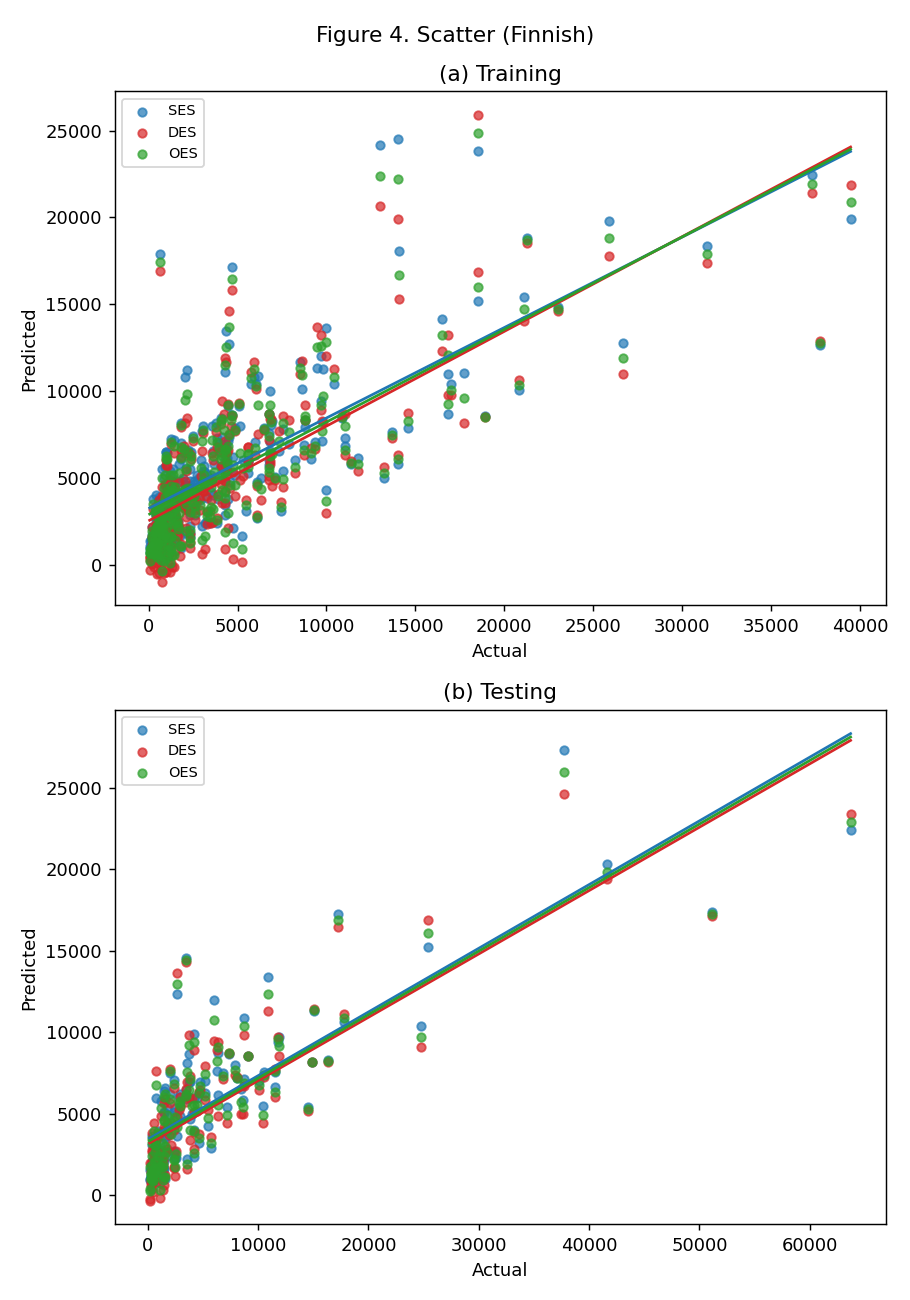

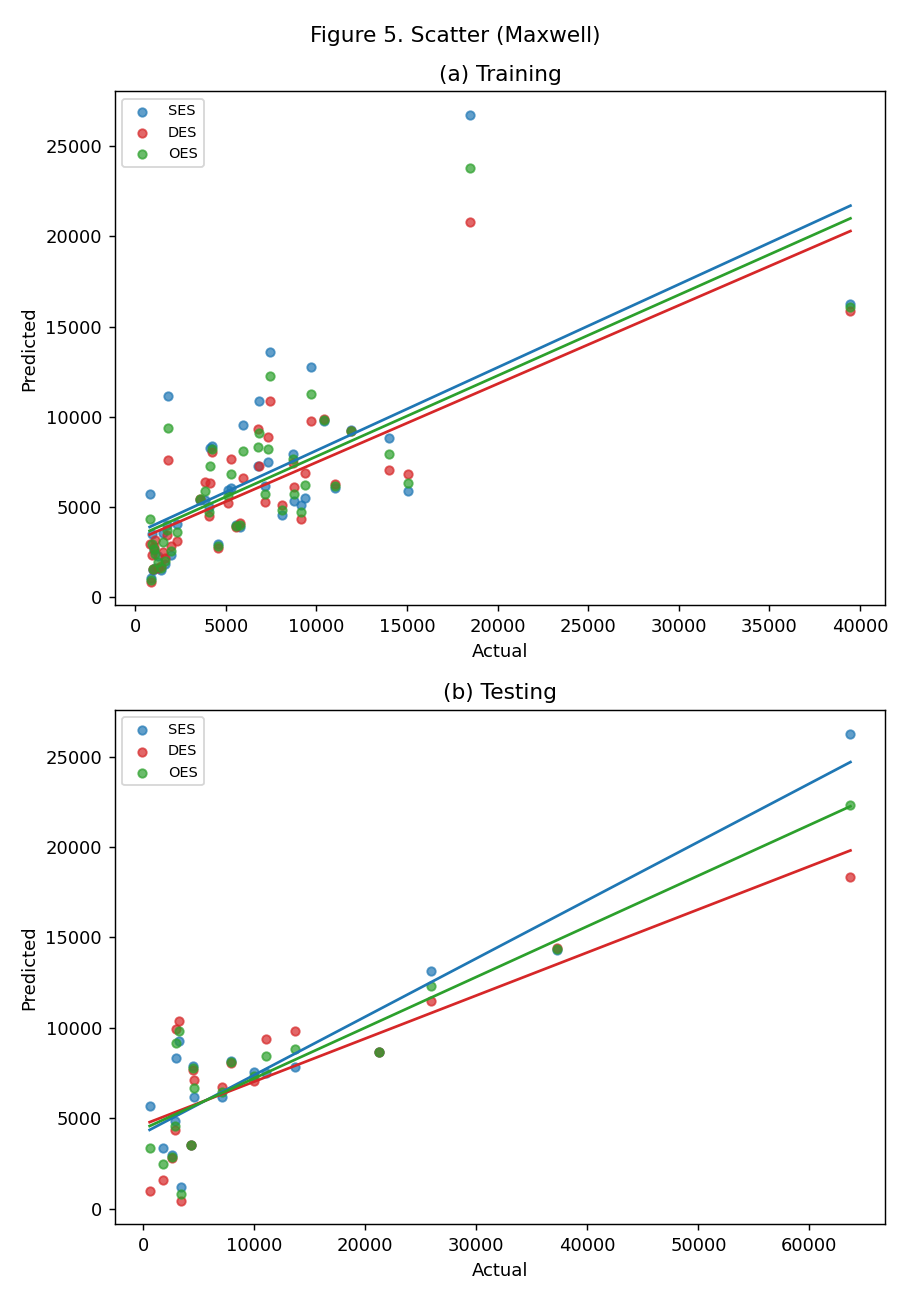

In [10]:
ens_tr_fin = {"SES": sel_fin["ses_tr"], "DES": ens_fin["des_tr"], "OES": ens_fin["oes_tr"]}
ens_te_fin = {"SES": sel_fin["ses_te"], "DES": ens_fin["des_te"], "OES": ens_fin["oes_te"]}
fg.scatter_fig(str(OUT_FIG / "fig4_finnish_scatter.png"), "Figure 4. Scatter (Finnish)",
               ens_tr_fin, ens_te_fin, d_fin["y_train_raw"], d_fin["y_test_raw"])

ens_tr_mx = {"SES": sel_mx["ses_tr"], "DES": ens_mx["des_tr"], "OES": ens_mx["oes_tr"]}
ens_te_mx = {"SES": sel_mx["ses_te"], "DES": ens_mx["des_te"], "OES": ens_mx["oes_te"]}
fg.scatter_fig(str(OUT_FIG / "fig5_maxwell_scatter.png"), "Figure 5. Scatter (Maxwell)",
               ens_tr_mx, ens_te_mx, d_mx["y_train_raw"], d_mx["y_test_raw"])

display(Image(str(OUT_FIG / "fig4_finnish_scatter.png")))
display(Image(str(OUT_FIG / "fig5_maxwell_scatter.png")))

## Figuras 6 e 7 — Radar sMAPE × COD
Um eixo por modelo, duas séries (sMAPE e COD×100), evidenciando a relação
inversa: quando o erro cai, a correlação sobe.

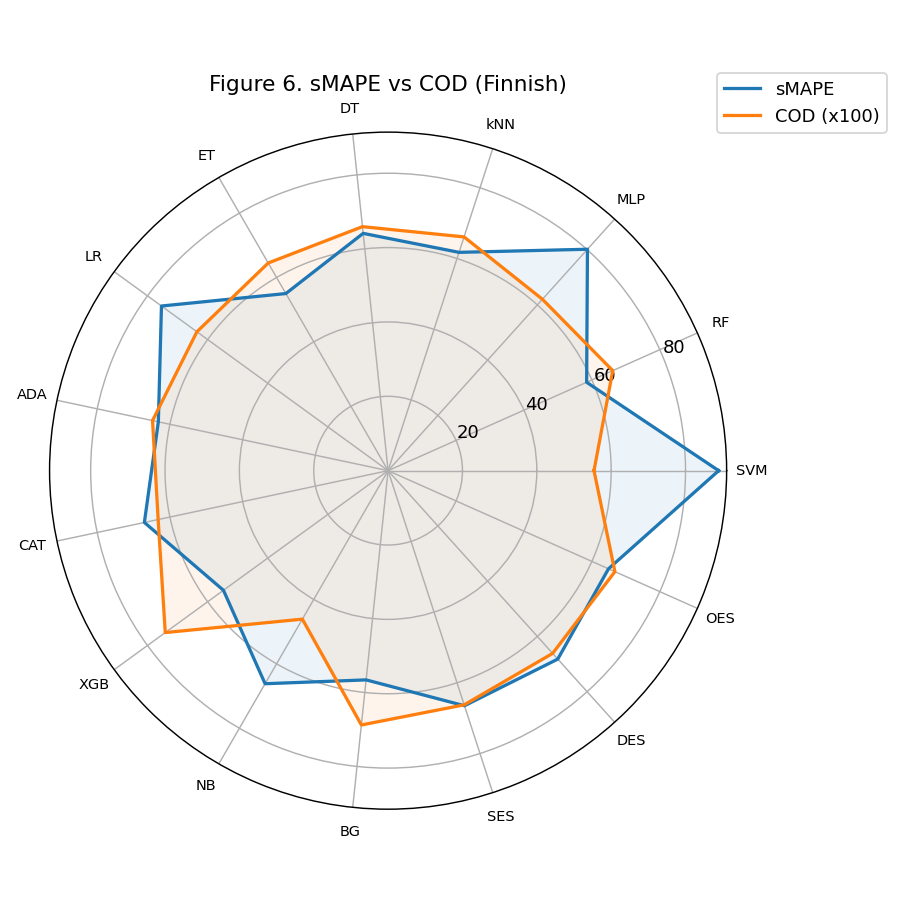

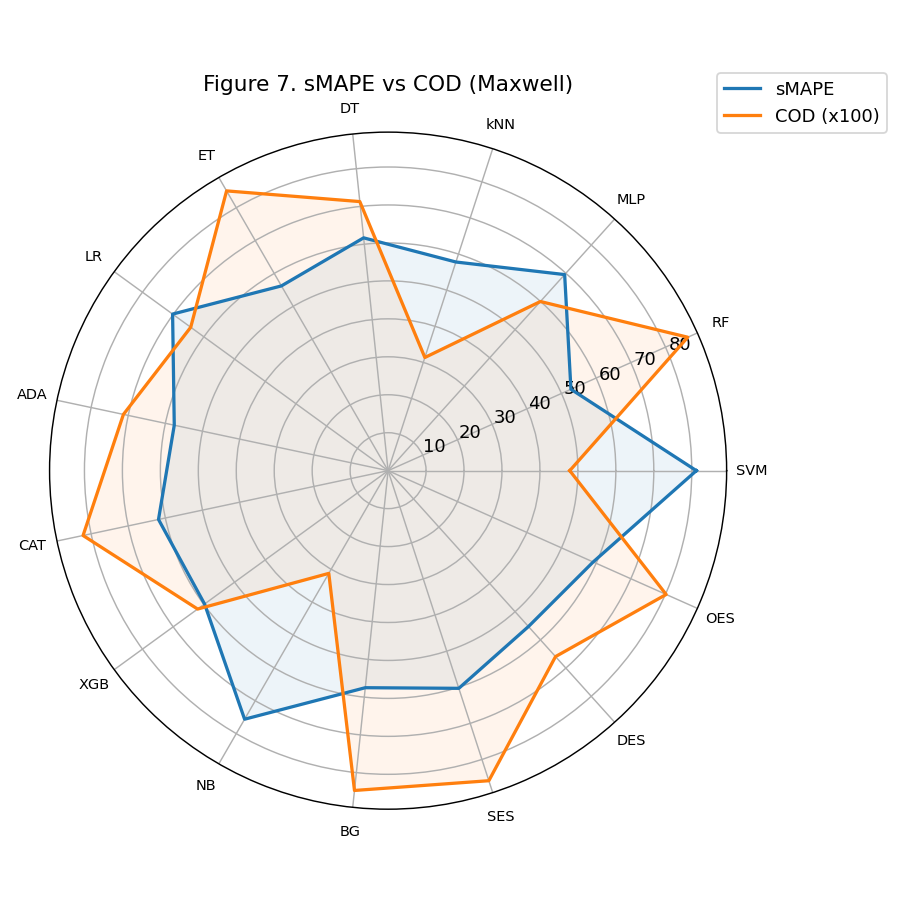

In [11]:
lab, s, c = tb.radar_inputs(rows_fin)
fg.radar_fig(str(OUT_FIG / "fig6_finnish_radar.png"), "Figure 6. sMAPE vs COD (Finnish)", lab, s, c)
lab, s, c = tb.radar_inputs(rows_mx)
fg.radar_fig(str(OUT_FIG / "fig7_maxwell_radar.png"), "Figure 7. sMAPE vs COD (Maxwell)", lab, s, c)

display(Image(str(OUT_FIG / "fig6_finnish_radar.png")))
display(Image(str(OUT_FIG / "fig7_maxwell_radar.png")))

## Relatório final
Gera `outputs/report.md` com as checagens, as tabelas comparativas, os
pressupostos e a discussão.

In [12]:
from report import build_report

log = [f"finnish: SES-GA -> {sel_fin['sel_names']}",
       f"maxwell: SES-GA -> {sel_mx['sel_names']}"]
res = {
    "finnish": {"d": d_fin, "rows": rows_fin, "wil": wil_fin,
                "sel_names": sel_fin["sel_names"],
                "ens_train": ens_tr_fin, "ens_test": ens_te_fin},
    "maxwell": {"d": d_mx, "rows": rows_mx, "wil": wil_mx,
                "sel_names": sel_mx["sel_names"],
                "ens_train": ens_tr_mx, "ens_test": ens_te_mx},
}
path = build_report(str(ROOT), res, t4, t5, t6, log,
                    tb.METRIC_COLS, tb.ROW_ORDER, mdl.POOL_ORDER)
print("Relatorio gravado em:", path)

Relatorio gravado em: /workspaces/rp_hybrid_system_with_ensemble/outputs/report.md
